In [1]:
%load_ext autoreload
%autoreload 2
import os, sys

import sys
sys.path.append("../")

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import bisect
from tqdm import tqdm
from ipywidgets import interact
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from scipy import signal

from src.fmcw_simulation.simulation import FmcwRadar
from src.py_network.adaptive_resonate import AdaptiveResonate

plt.rc('xtick',labelsize=25)
plt.rc('ytick',labelsize=25)
# mpl.rcParams['figure.dpi'] = 200 
mpl.rcParams['figure.figsize'] = (12, 9) 
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['axes.labelsize'] = 25
mpl.rcParams['legend.fontsize'] = 20
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#003052", "#C71818", "#18C7C7", "#70C718", "#7018C7"])
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#6ba0a6", "#d8584e", "#c09651", "#f8c08a", "#8e4f39"])

In [2]:
radar_config = {
    "n_rx": 1,
    "fb" : 77e9,
    "B" : 1.5e9,
    "n_chirps": 64,
    "n_samples": 128*1,
    "t_chirp": 40e-6*1,
    "IQ": True,
    "noise_std": 0.1
}
# radar_config = {
#     "n_rx": 1,
#     "fb" : 76e9,
#     "B" : 500e6,
#     "n_chirps": 64,
#     "n_samples": 256,
#     "t_chirp": 50e-6,
#     "IQ": True,
#     "noise_std": 0.000001
# }
fmcw = FmcwRadar(radar_config)

In [3]:
fmcw = FmcwRadar(config=radar_config)
fmcw.target_snr_db = 200
# targets = [
#     {
#         "range":0.5,
#         "velocity": -5.0,
#         "angle": np.deg2rad(0)
#     },
#     {
#         "range":6.5,
#         "velocity": 4,
#         "angle": np.deg2rad(0)
#     },
#     {
#         "range":8.5,
#         "velocity": -2.5,
#         "angle": np.deg2rad(0)
#     },
#     {
#         "range":3.5,
#         "velocity": 1,
#         "angle": np.deg2rad(0)
#     },
# ]

targets = [
    # Original 4 targets (kept identical)
    {
        "range": 0.5,
        "velocity": -5.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 6.5,
        "velocity": 8.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 8.5,
        "velocity": -2.5,
        "angle": np.deg2rad(0)
    },
    {
        "range": 3.5,
        "velocity": 1.0,
        "angle": np.deg2rad(0)
    },
    # 8 New targets well-spaced across the Range-Doppler grid
    {
        "range": 1.8,
        "velocity": 5.5,
        "angle": np.deg2rad(0)
    },
    {
        "range": 2.5,
        "velocity": -1.5,
        "angle": np.deg2rad(0)
    },
    {
        "range": 4.8,
        "velocity": -10.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 5.5,
        "velocity": 2.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 7.2,
        "velocity": -6.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 9.8,
        "velocity": 12.5,
        "angle": np.deg2rad(0)
    },
    {
        "range": 11.0,
        "velocity": 3.0,
        "angle": np.deg2rad(0)
    },
    {
        "range": 12.5,
        "velocity": -3.0,
        "angle": np.deg2rad(0)
    },
]

fmcw.set_targets(targets)
frame = fmcw.generate_data_snr()

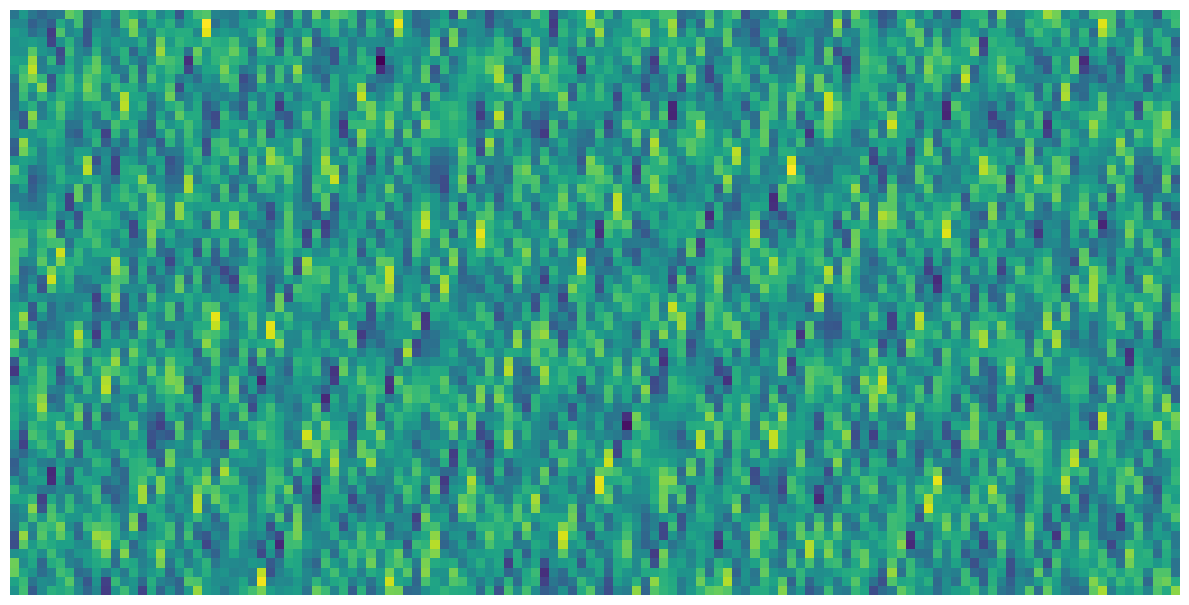

In [4]:
plt.imshow(frame[0].real, interpolation='none')
plt.axis('off')
plt.tight_layout()
plt.savefig("paper_figures/doppler_full_frame.svg", bbox_inches='tight')

/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chistefano/code/tue/frequency_adaptive_clean/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


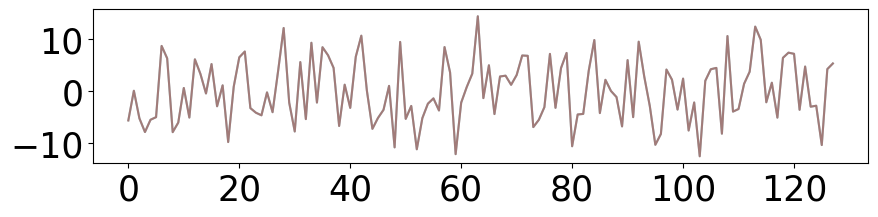

In [5]:
plt.figure(figsize=(10, 2))
plt.plot(fmcw.pure_signal[0, 0, :].flatten())
plt.plot(frame[0, 0, :], alpha=0.5)
# plt.plot(frame[0, 1, :].flatten())

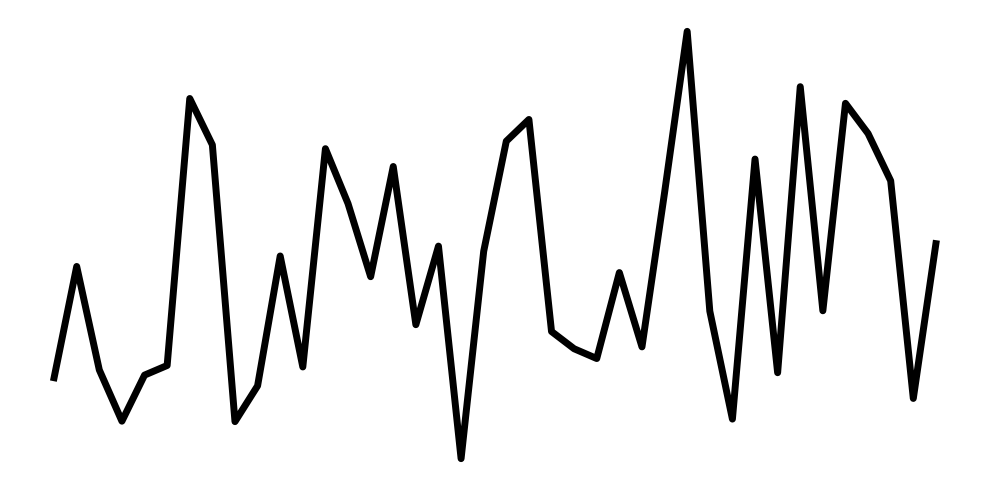

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(frame[0, 0, :40], c='black', linewidth=5)
plt.axis('off');

plt.tight_layout()
plt.savefig("figures/doppler_signal_plot.svg", bbox_inches='tight', transparent=True)

In [7]:
ranges = fmcw.get_ranges()
vels = fmcw.get_velocities()
angles = fmcw.get_angles()

In [8]:
n_units = len(targets)
t_max = fmcw.t_chirp * fmcw.n_chirps
res_net = AdaptiveResonate(
            n_units, 
            t_max, 
            fmcw.t_chirp / fmcw.n_samples, 
            k=1,
            feedback=True,
            w_scale= np.ones((fmcw.n_rx, n_units))*40e-6*0.5,
            n_rxs=fmcw.n_rx
)

# res_net.spike_condition = res_net.period_spiking
res_net.normalize_input = False
res_net.normalize_neuron = True

res_net.alpha_lpf = 0.5

min_starting_freq = 2
max_starting_freq = 30

res_net.wdot_mode = False
fmcw.random_Ap = False

sampling_rate = fmcw.n_samples / fmcw.t_chirp
max_start_freq = sampling_rate / 4

for rx in range(fmcw.n_rx):
    max_range = fmcw.max_range / 2
    start_ranges = ((np.linspace(0.1, max_range, res_net.nfreq)))
    start_freqs = fmcw.get_freq_from_range(start_ranges)
    print(start_ranges)
    res_net.ws[:] = start_freqs * 2 * np.pi
    
res_net.periods = ((2 * np.pi) / (res_net.ws * res_net.t_res)).astype(int)
# res_net.enable_rx_lock()

# for i in range(res_net.total_neurons):
#         res_net.ws_locking_matrix[i*n_units:(i+1)*n_units, i*n_units:(i+1)*n_units] = 1

[0.1        0.67272727 1.24545455 1.81818182 2.39090909 2.96363636
 3.53636364 4.10909091 4.68181818 5.25454545 5.82727273 6.4       ]


In [9]:
res_net.ws.shape

(1, 12)

In [10]:
frames_to_use = 1
ws_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units))
w_dot_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units), dtype=complex)
vs_hist = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units), dtype=complex)
spikes_out = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx, n_units))
flat_frame = frame.reshape((frame.shape[0], -1))
# input_w_feedback = np.zeros((res_net.n_steps * frames_to_use, fmcw.n_rx))
gt_ranges = []

for f in tqdm(range(frames_to_use)):
    
    frame = fmcw.generate_data_snr()
    frame = fmcw.apply_hann(frame)
    flat_frame = frame.reshape((frame.shape[0], -1))

    # for i in range(flat_frame.shape[-1]):
    #     ws_hist[i+f*res_net.n_steps] = res_net.ws
    #     vs_hist[i+f*res_net.n_steps] = res_net.vs
    #     # input_w_feedback[i+f*res_net.n_steps] = res_net.neuron_input
    #     w_dot_hist[i+f*res_net.n_steps] = res_net.w_dot

    #     spikes = res_net.update_neurons(np.copy(flat_frame[:, i]))
    #     spikes_out[i + f*res_net.n_steps] = spikes
    #     gt_ranges.append(fmcw.targets_info[0]['range'])
    vs_hist_tmp, ws_hist_tmp = res_net.update_neurons_c(flat_frame)

    ws_hist[f*res_net.n_steps:(f+1)*res_net.n_steps] = ws_hist_tmp
    vs_hist[f*res_net.n_steps:(f+1)*res_net.n_steps] = vs_hist_tmp

    # for t in fmcw.targets_info:
    #     t['range'] += t['velocity'] * fmcw.t_chirp * fmcw.n_chirps
    # print(fmcw.targets_info[0]['range'])

gt_ranges = np.array(gt_ranges)

100%|██████████| 1/1 [00:00<00:00, 54.73it/s]


In [11]:
range_hist = fmcw.get_range_from_freq(ws_hist / (2 * np.pi))

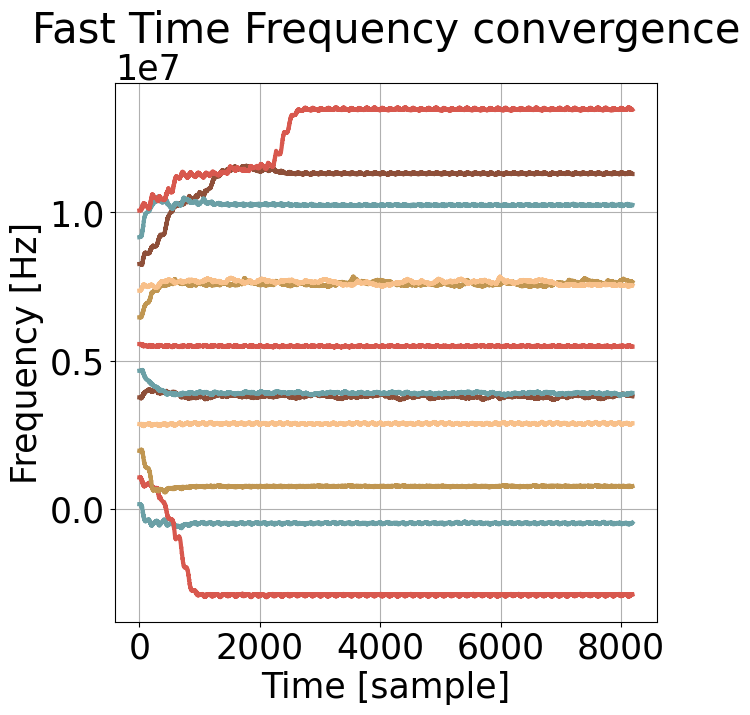

In [12]:
fig, ax = plt.subplots(1, figsize=(7, 7))

ax.plot(ws_hist.squeeze()[:], linewidth=3)
ax.grid()

ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [sample]")

ax.set_title("Fast Time Frequency convergence")

plt.savefig("paper_figures/doppler_fasttime_convergence.svg", bbox_inches='tight')

In [13]:
if vs_hist.size == ws_hist.size * 2:
    vs_hist_frame = vs_hist[::2].reshape((fmcw.n_chirps*frames_to_use, fmcw.n_samples, n_units))
else:
    vs_hist_frame = vs_hist.reshape((fmcw.n_chirps*frames_to_use, fmcw.n_samples, n_units))

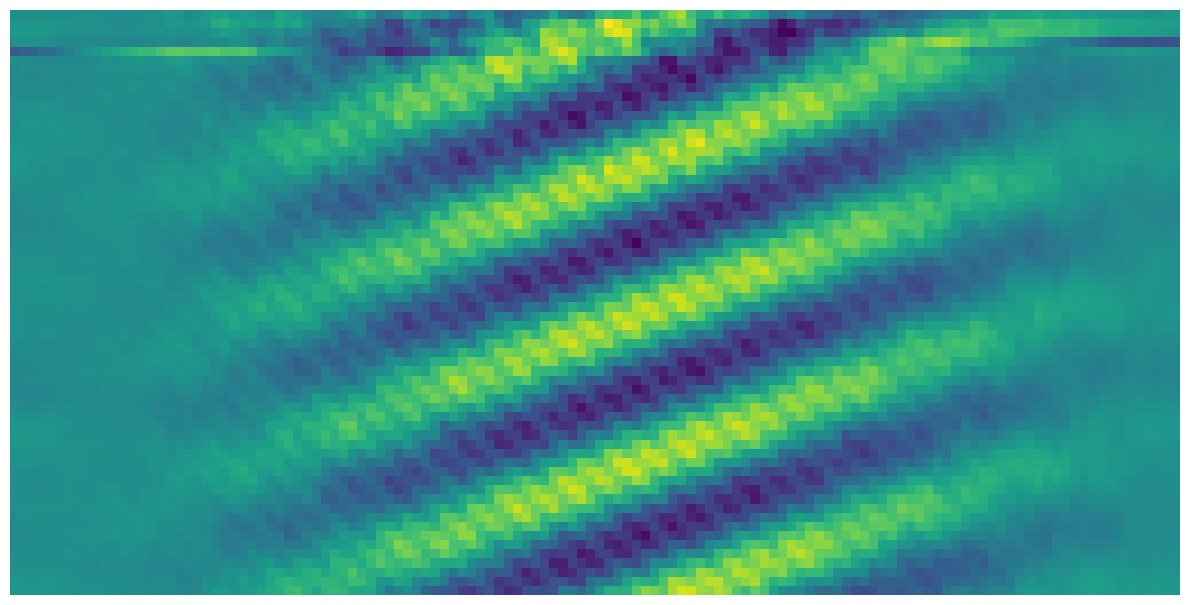

In [14]:
plt.imshow(np.real(vs_hist_frame[:, :, 0]))
plt.axis('off')
plt.tight_layout()
plt.savefig("paper_figures/doppler_decomposed_frame_1.svg", bbox_inches='tight')

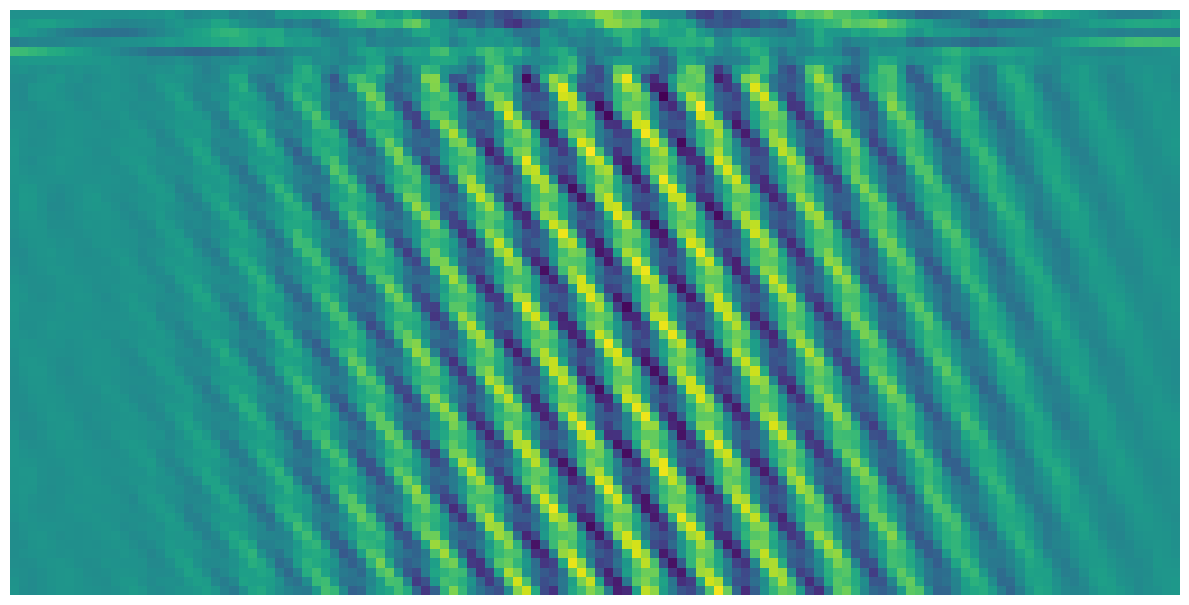

In [15]:
if n_units > 1:
    plt.imshow(np.real(vs_hist_frame[:, :, 1]))
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("paper_figures/doppler_decomposed_frame_2.svg", bbox_inches='tight')

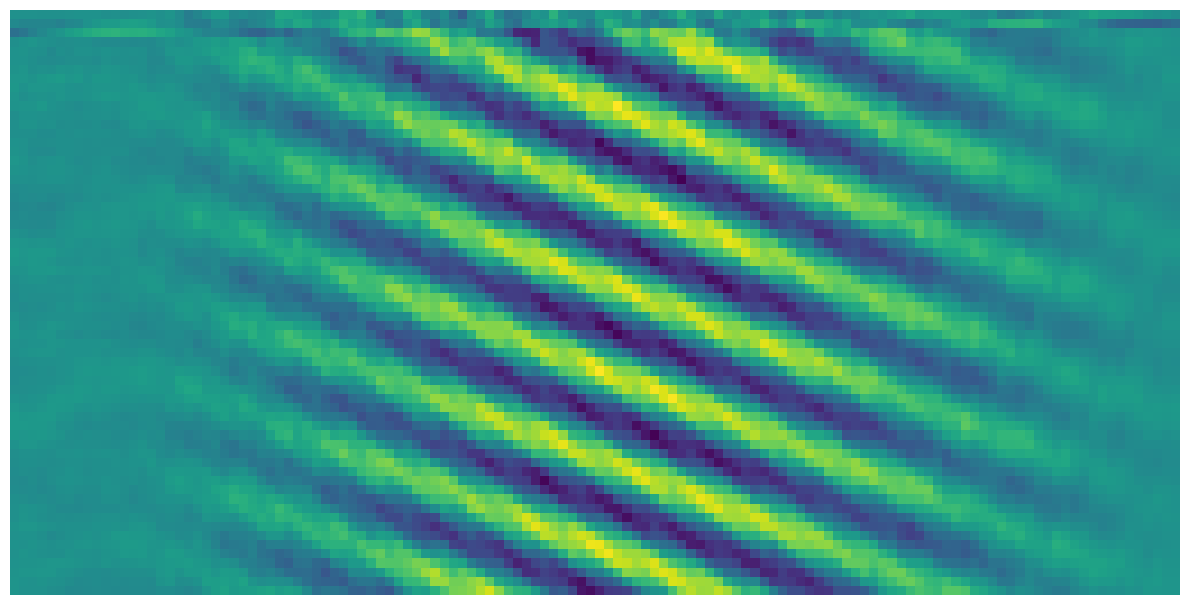

In [16]:
if n_units > 2:
    plt.imshow(np.real(vs_hist_frame[:, :, 2]))
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("paper_figures/doppler_decomposed_frame_3.svg", bbox_inches='tight')

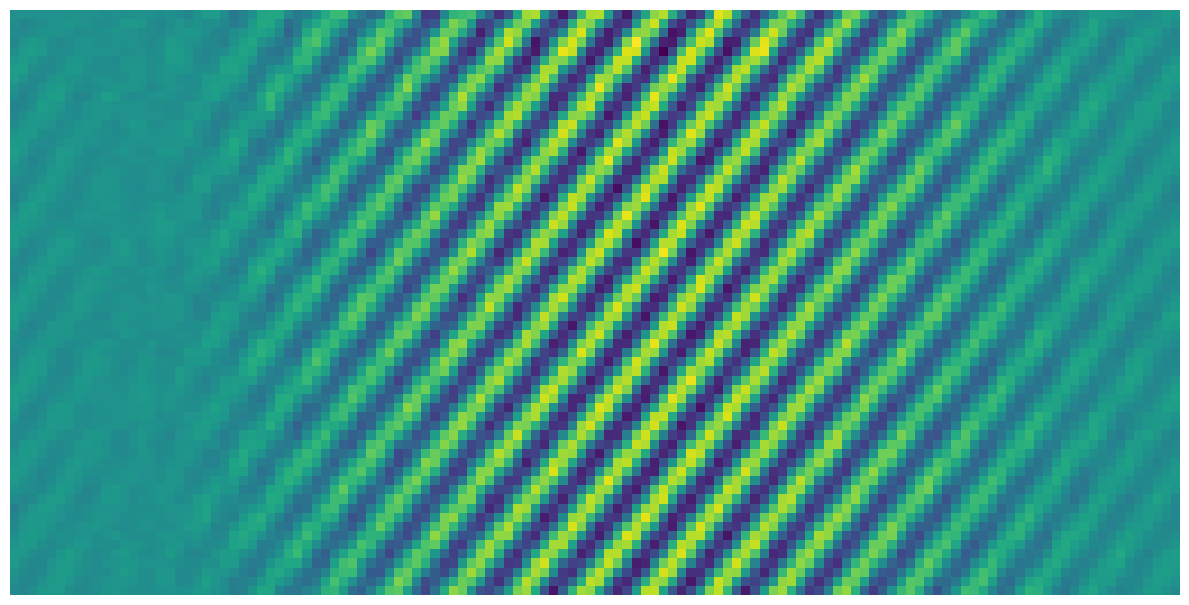

In [17]:
if n_units > 3:
    plt.imshow(np.real(vs_hist_frame[:, :, 3]))
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("paper_figures/doppler_decomposed_frame_4.svg", bbox_inches='tight')

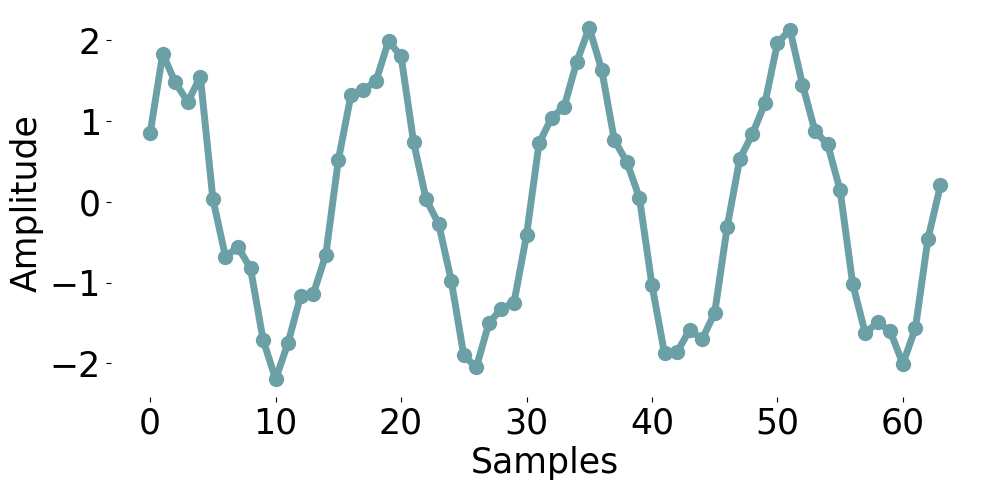

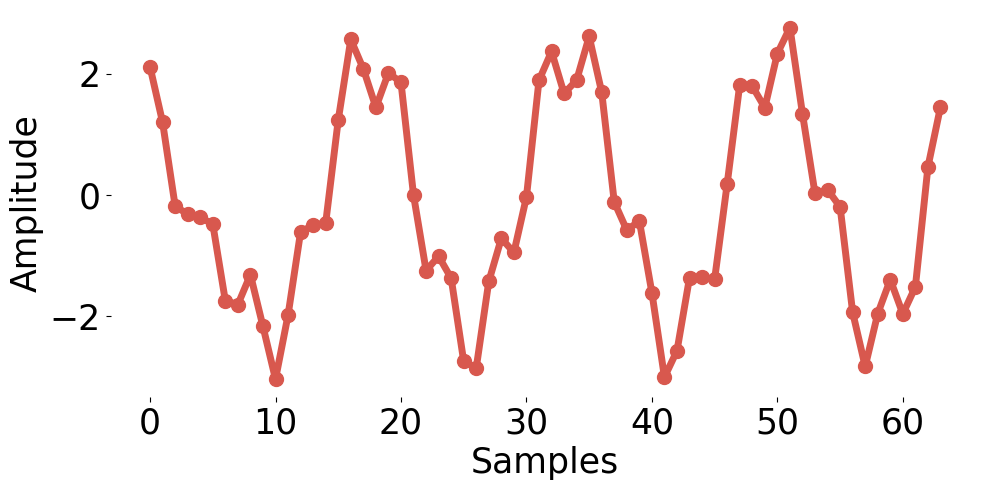

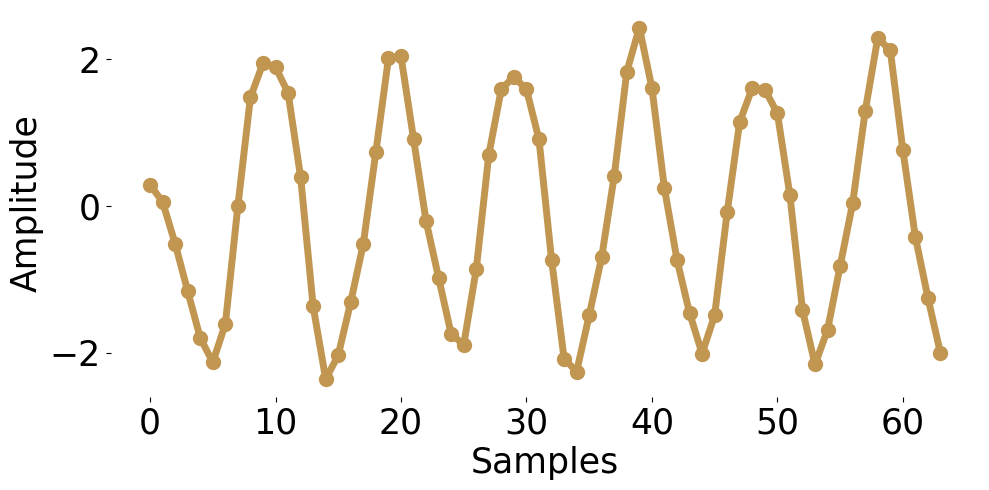

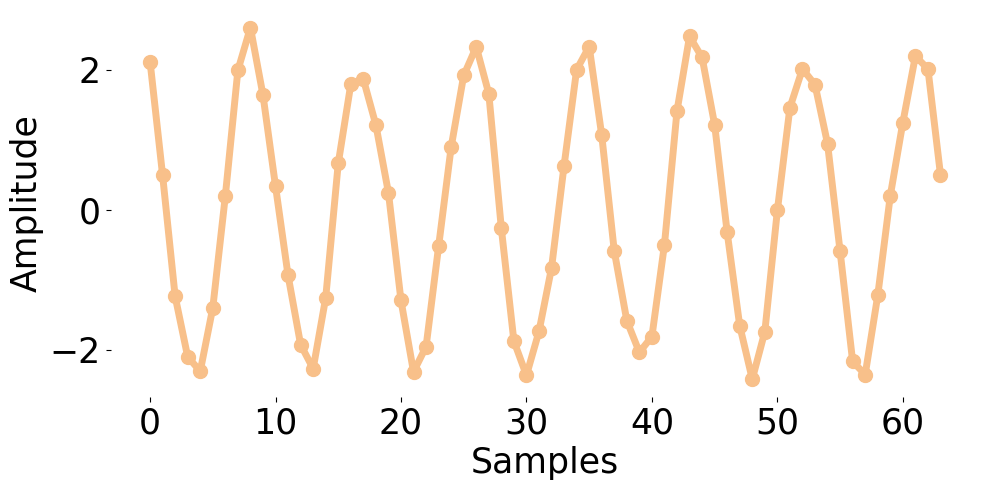

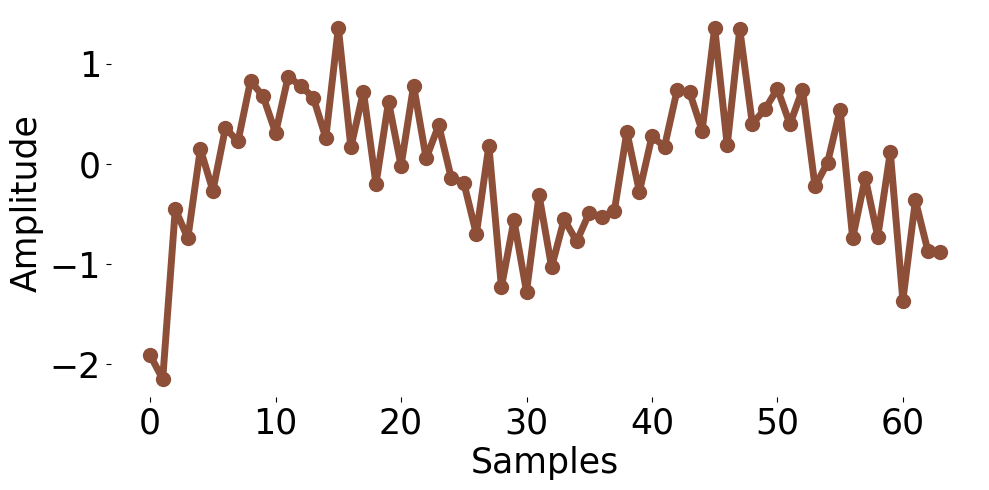

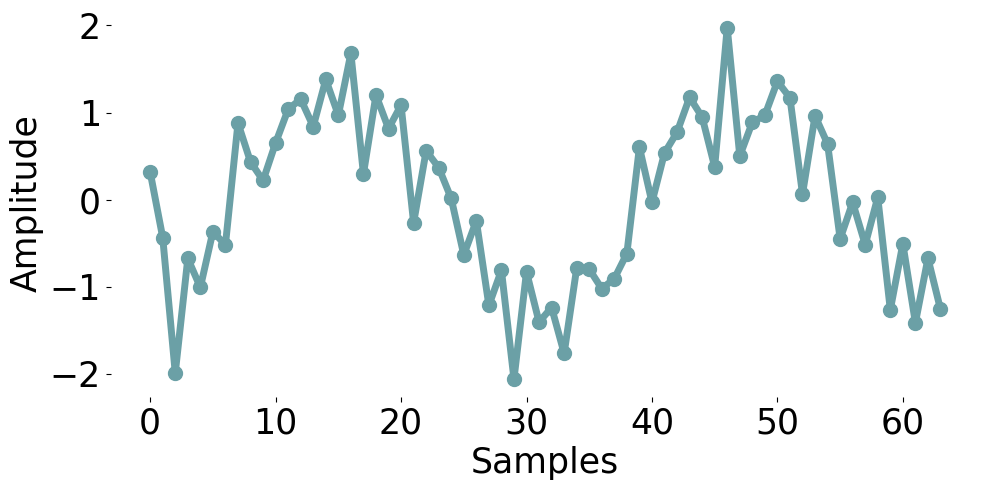

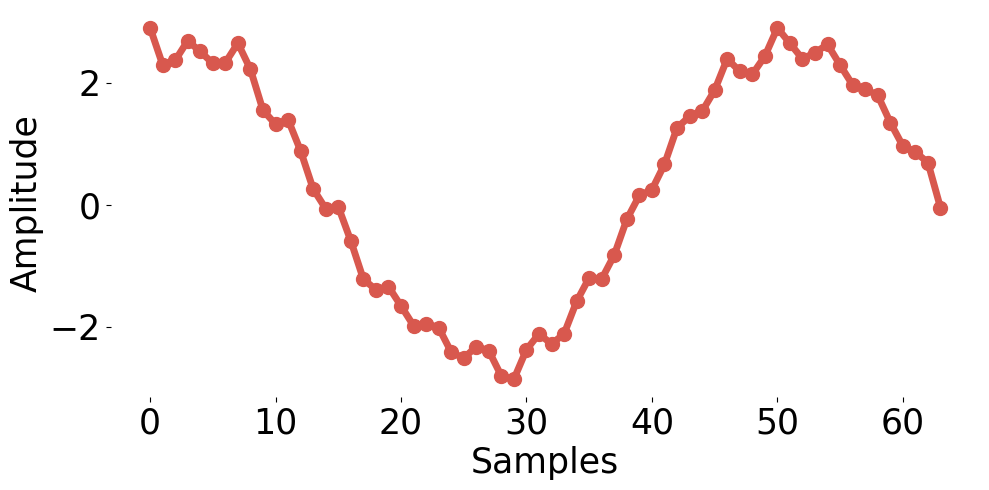

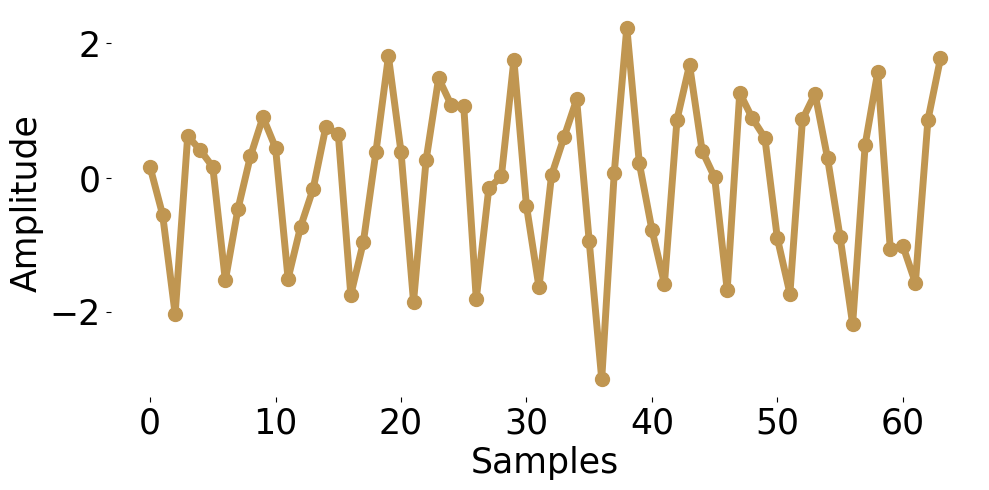

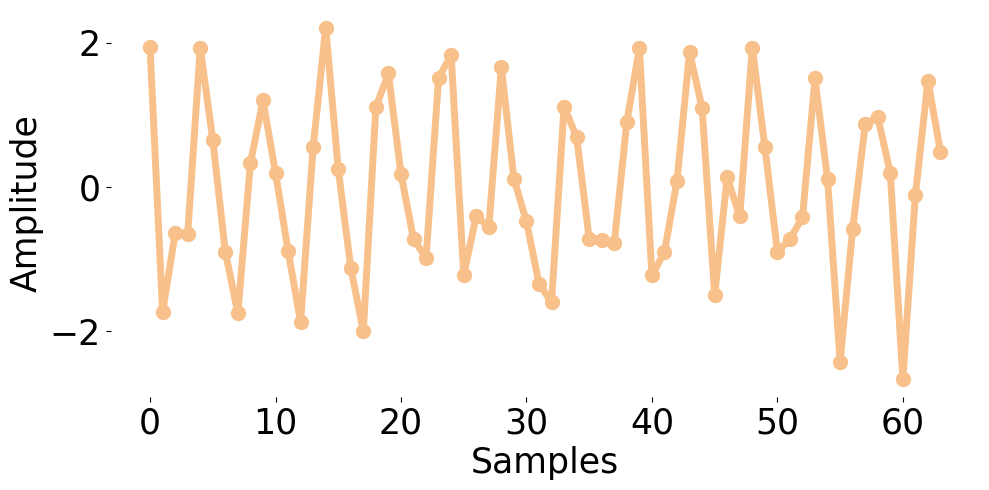

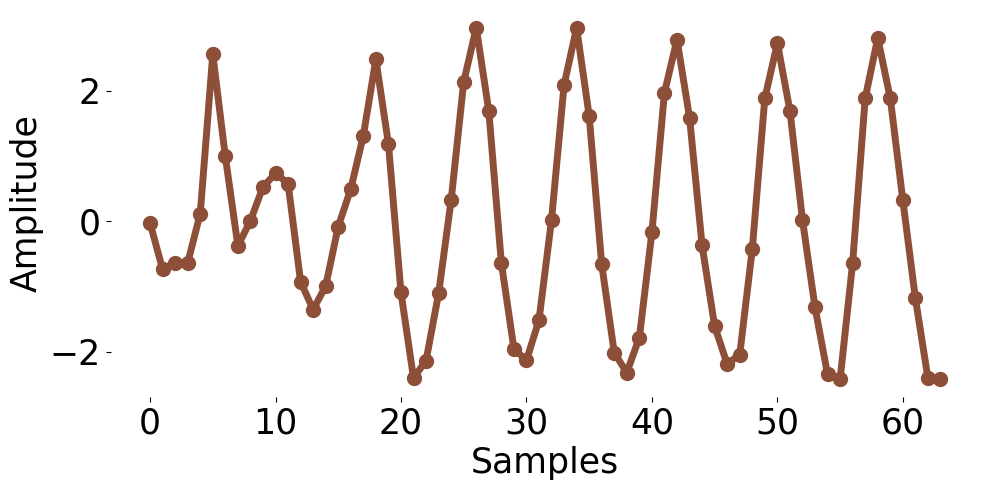

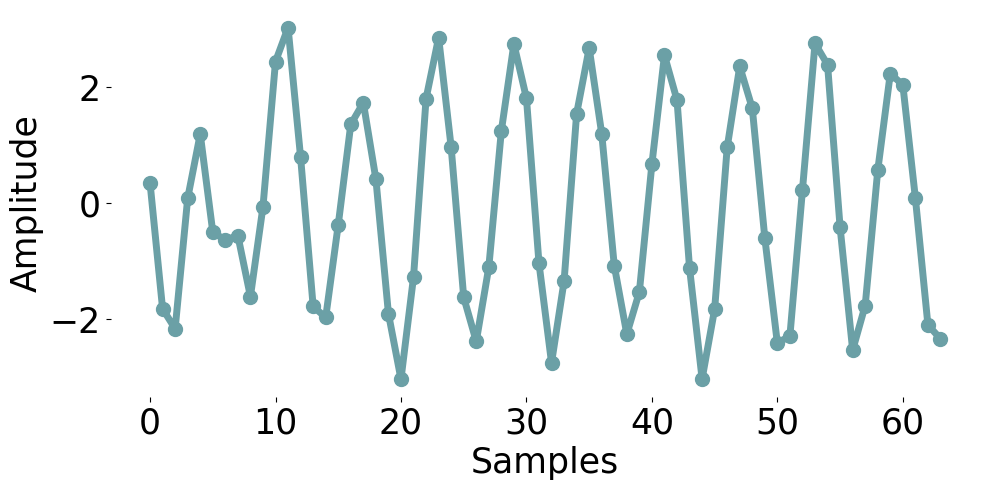

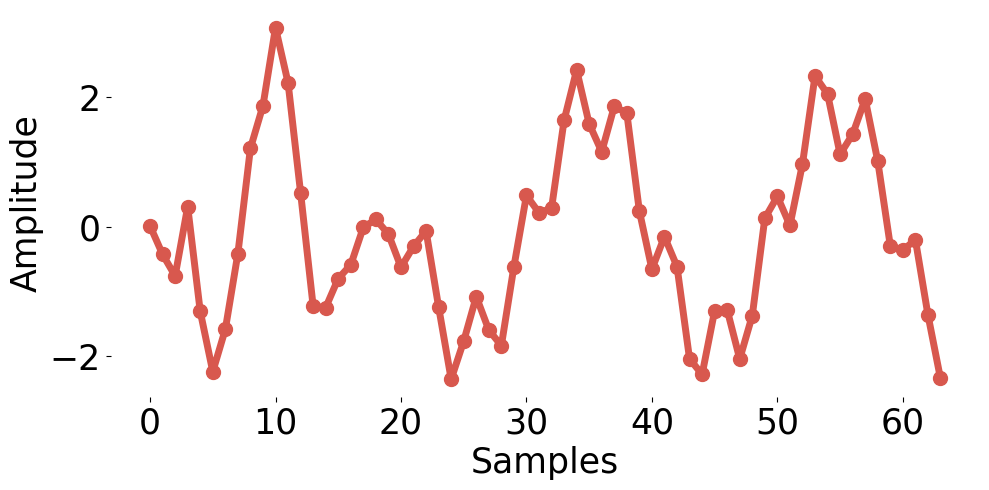

In [18]:
for i in range(vs_hist_frame.shape[-1]):
    fig, ax = plt.subplots(1, figsize=(10, 5))
    ax.plot(vs_hist_frame[:, fmcw.n_samples // 2, i], linewidth=5, c=f"C{i}", marker='o', markersize=10)
    # plt.axis('off')
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude")
    plt.tight_layout()
    plt.savefig(f"paper_figures/doppler_signal_{i}.svg", bbox_inches='tight', transparent=True)

In [19]:
doppler_signal = vs_hist_frame[:, fmcw.n_samples // 2, :]
doppler_signal = np.swapaxes(doppler_signal, 0, -1)

In [20]:
n_units_doppler = 1
t_max = fmcw.t_chirp * fmcw.n_chirps
res_net_doppler = AdaptiveResonate(
            n_units_doppler, 
            t_max, 
            fmcw.t_chirp, 
            k=1,
            feedback=True,
            w_scale= np.ones((len(targets), n_units))*t_max*0.2,
            n_rxs=len(targets)
)

res_net_doppler.normalize_input = False
res_net_doppler.normalize_neuron = True

min_starting_freq = 2
max_starting_freq = 30

for rx in range(fmcw.n_rx):
    res_net_doppler.ws[rx] = ((np.linspace(2, 49, res_net_doppler.nfreq)) * 2 * np.pi) / t_max
    
    
res_net_doppler.periods = ((2 * np.pi) / (res_net_doppler.ws * res_net_doppler.t_res)).astype(int)

In [21]:
def apply_hann(frame):

    new_frame = np.zeros_like(frame)

    hann_w = np.hanning(frame.shape[1])[None, :]

    # remove DC per chirp
    # frame = frame - frame.mean(axis=2, keepdims=True)

    # apply window
    new_frame = frame * hann_w

    return new_frame
        

In [22]:
for i in range(n_units):    
    doppler_signal[i] = apply_hann(doppler_signal[i].reshape(-1, frame.shape[1])).flatten()

In [23]:
vs_hist_doppler, ws_hist_doppler = res_net_doppler.update_neurons_c(doppler_signal)


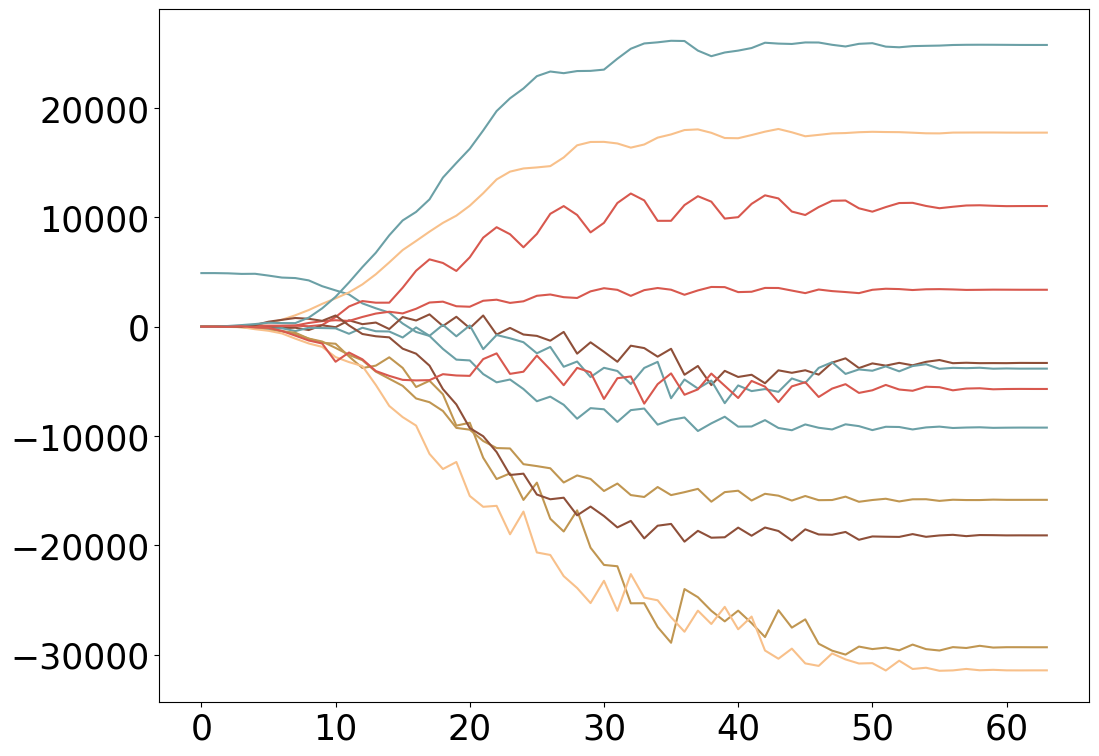

In [24]:
plt.plot(ws_hist_doppler.squeeze())

In [25]:
vel_hist = fmcw.doppler_frequency_to_velocity(ws_hist_doppler / (2 * np.pi))

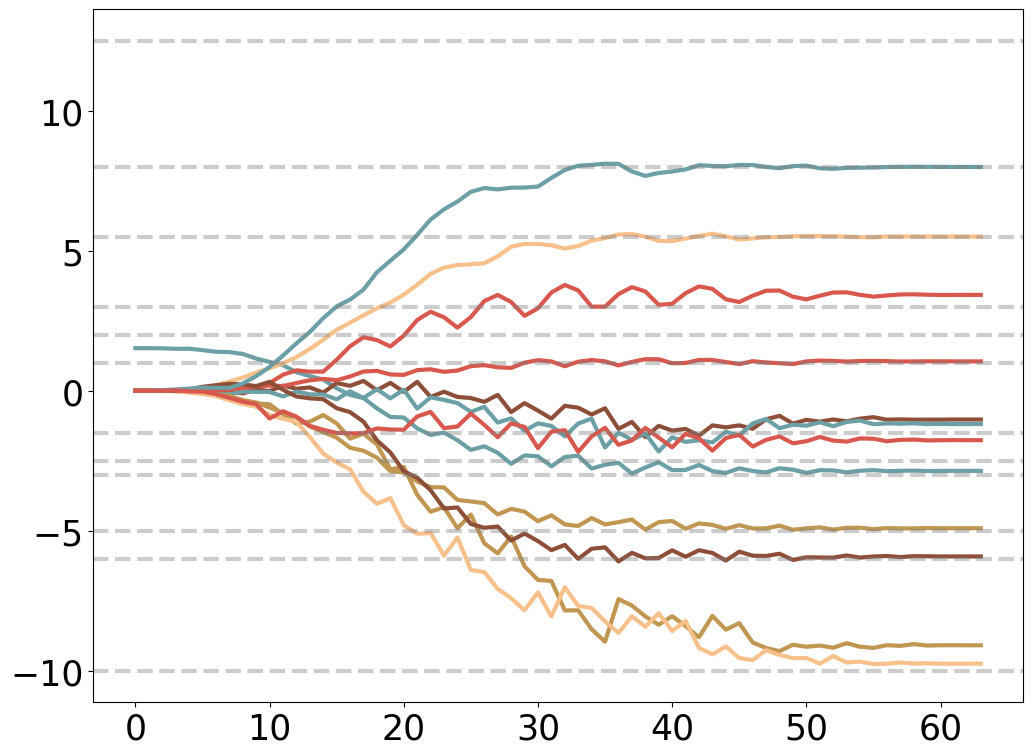

In [26]:
plt.plot(vel_hist.squeeze(), linewidth=3)
for t in targets:
    plt.axhline(t['velocity'], linewidth=3, linestyle="--", alpha=0.4, c="grey")

In [27]:
ranges = range_hist[-1]
velocities = vel_hist[-1]
ranges = np.tile(ranges.squeeze(), (n_units_doppler, 1)).T.flatten()

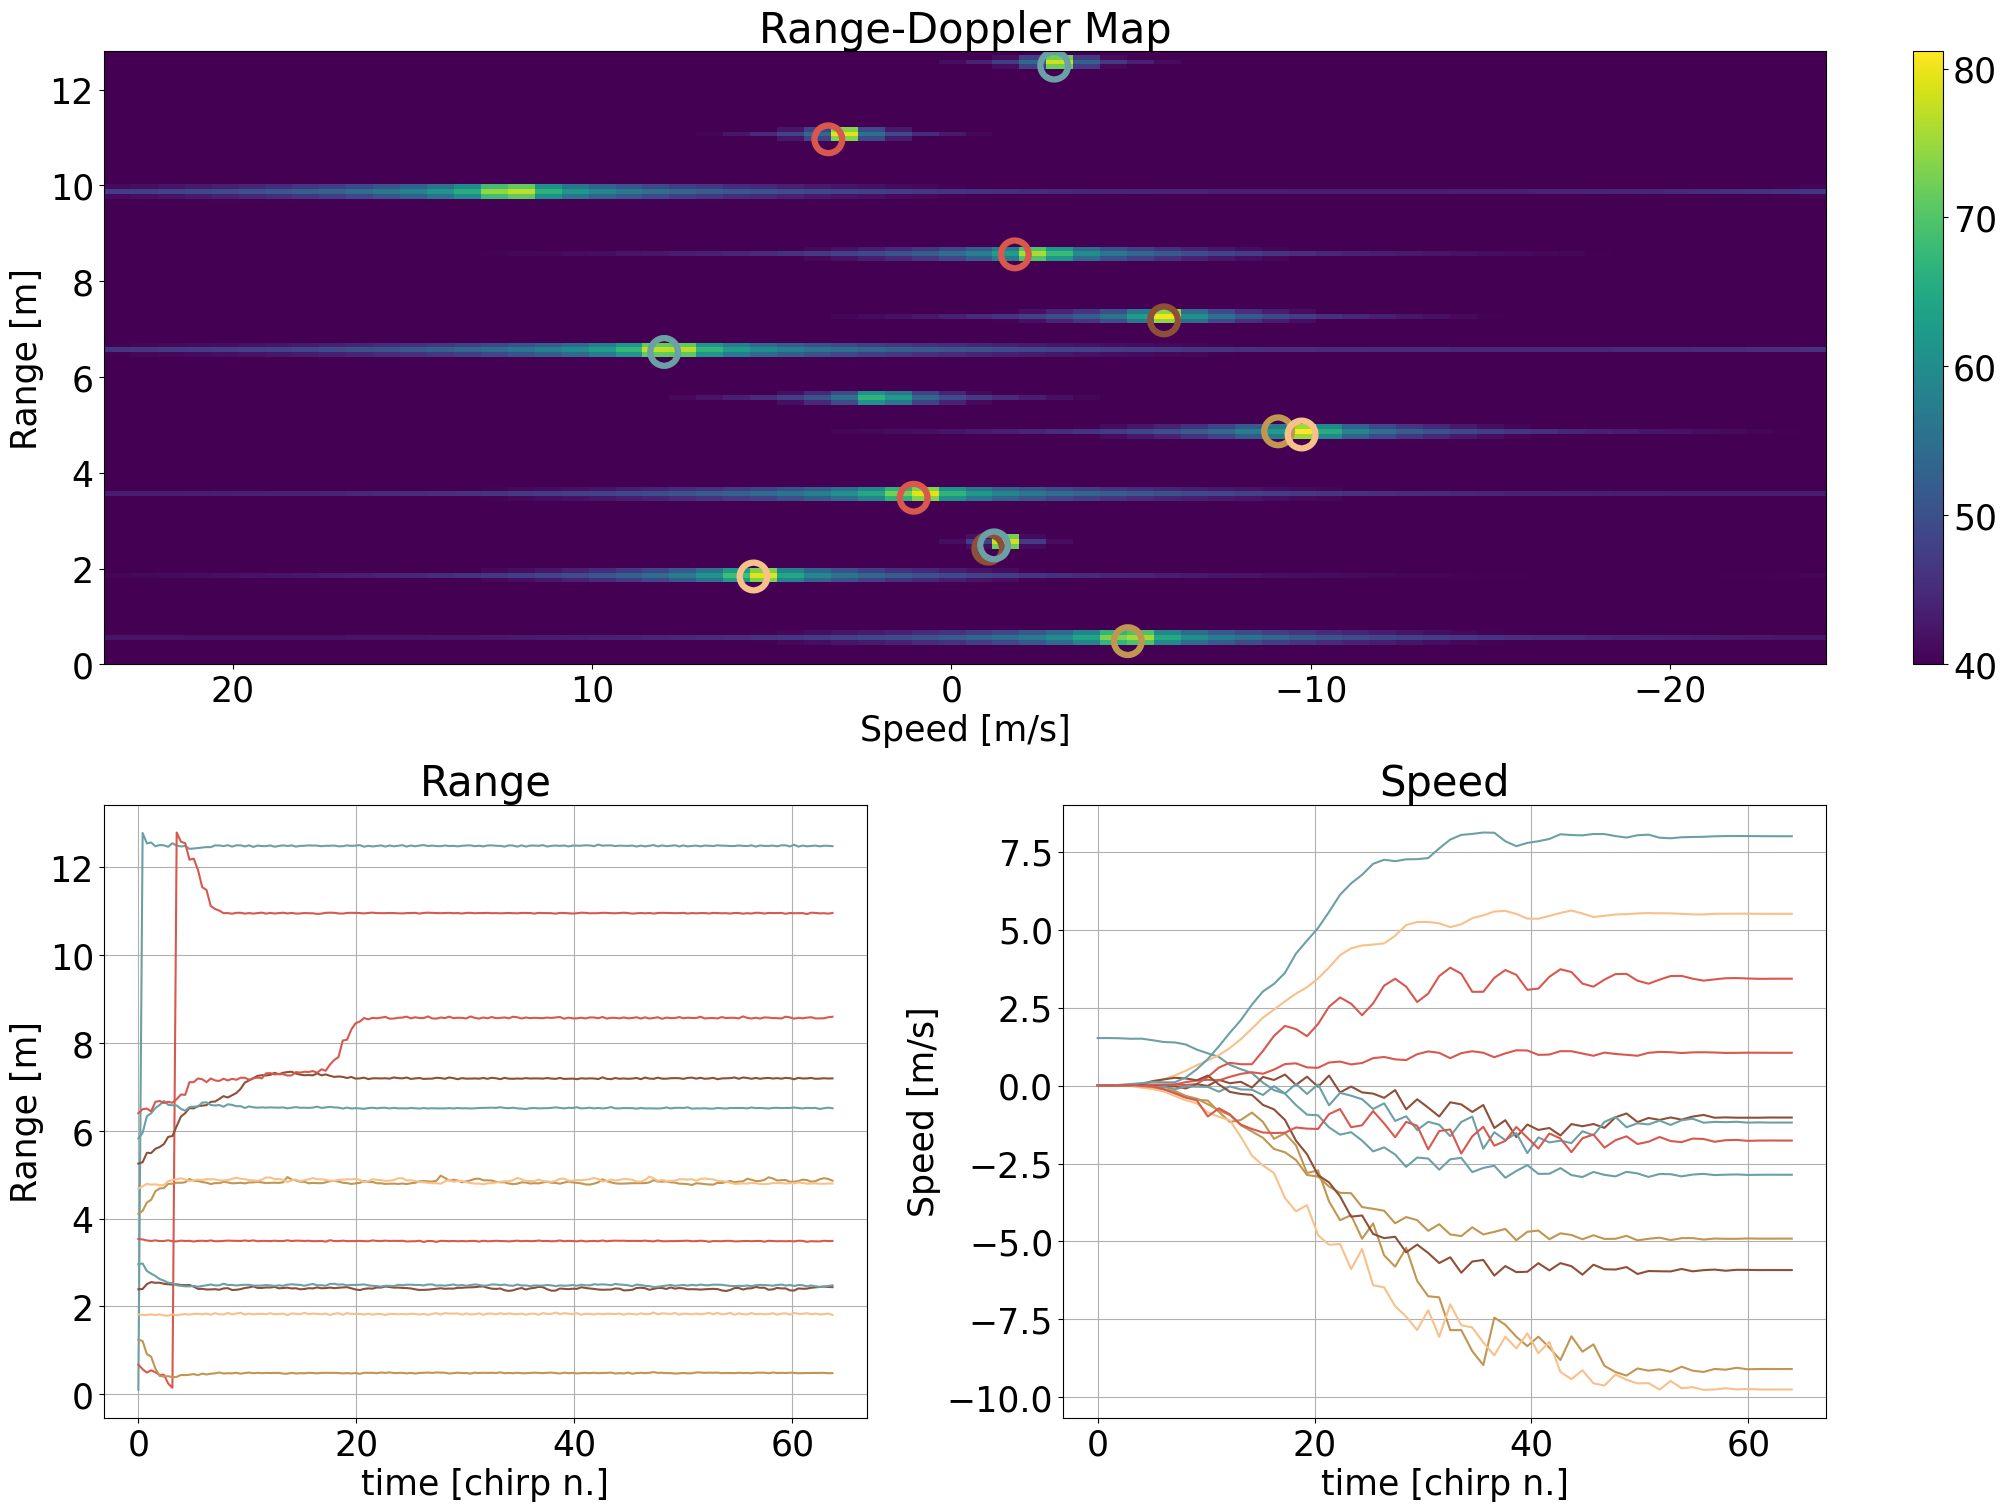

In [28]:
fig = plt.figure(layout="constrained", figsize=(20, 15))

gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :-1])
ax3 = fig.add_subplot(gs[1, -1])
# ax4 = fig.add_subplot(gs[2, :])

fft2 = np.fft.fft2(frame[-1].T)
fft2 = np.fft.fftshift(fft2, axes=1)
# fft2 = np.fft.fftshift(fft2, axes=0)
fft_db = 20*np.log10(np.abs(fft2))
full_ranges = fmcw.get_ranges2()
c = ax1.imshow(fft_db, 
               aspect='auto', 
               interpolation='none', 
               origin="lower", 
               extent=[
                        vels.min(),
                        vels.max(),
                        full_ranges[0],
                        full_ranges[-1]],
               vmin=40.0)
plt.colorbar(c, ax=ax1)

colors = [f"C{i}" for i in range(ranges.size)]
facecolors = ["none" for i in range(ranges.size)]

ax1.scatter(velocities, ranges, 
            edgecolors=colors, 
            facecolors=facecolors, 
            s=20, 
            linewidths=20)

total_chirps = frame.shape[1]
range_time = np.linspace(0, total_chirps, range_hist.shape[0])
vel_time = np.linspace(0, total_chirps, vel_hist.shape[0])

for i in range(n_units):
    ax2.plot(range_time[::50], range_hist.reshape(range_hist.shape[0], -1)[::50, i], 
             alpha=1 if ranges[i] > 0.1 else 0.3)

for i in range(n_units):
    ax3.plot(vel_time[::], vel_hist.reshape(vel_hist.shape[0], -1)[::, i], 
             alpha=1 if ranges[i] > 0.1 else 0.3)

# ax4.plot(np.abs(vs_hist_doppler[-1000:].squeeze()))

ax2.grid()
ax3.grid()

ax1.set_title("Range-Doppler Map")
ax2.set_title("Range")
ax3.set_title("Speed")

ax1.set_xlabel("Speed [m/s]")
ax1.set_ylabel("Range [m]")

ax2.set_xlabel("time [chirp n.]")
ax2.set_ylabel("Range [m]")

ax3.set_xlabel("time [chirp n.]")
ax3.set_ylabel("Speed [m/s]")

ax1.invert_xaxis()

# plt.savefig("../paper_figures/range_doppler_real_data_3targets.pdf", bbox_inches='tight')